In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math as ma

In [53]:
data1=pd.read_csv('Millikan Con Campo 1.csv')
data2=pd.read_csv('Millikan Sin Campo 1.csv')
data3=pd.read_csv('Millikan Con Campo 2.csv')
data4=pd.read_csv('Millikan Sin Campo 2.csv')

In [54]:
pos1=[]
tiem1=[]
pos2=[]
tiem2=[]
for i in range(0,26):
  x=data1.iloc[:, 2*i+1]
  t=data1.iloc[:, 2*i]
  x=[m for m in x if not np.isnan(m)]
  t=[n for n in t if not np.isnan(n)]
  pos2.append(x)
  tiem2.append(t)
for i in range(0,26):
  x=data2.iloc[:, 2*i+1]
  t=data2.iloc[:, 2*i]
  x=[m for m in x if not np.isnan(m)]
  t=[n for n in t if not np.isnan(n)]
  pos1.append(x)
  tiem1.append(t)
for i in range(0,25):
  x=data3.iloc[:, 2*i+1]
  t=data3.iloc[:, 2*i]
  x=[m for m in x if not np.isnan(m)]
  t=[n for n in t if not np.isnan(n)]
  pos2.append(x)
  tiem2.append(t)
for i in range(0,25):
  x=data4.iloc[:, 2*i+1]
  t=data4.iloc[:, 2*i]
  x=[m for m in x if not np.isnan(m)]
  t=[n for n in t if not np.isnan(n)]
  pos1.append(x)
  tiem1.append(t)

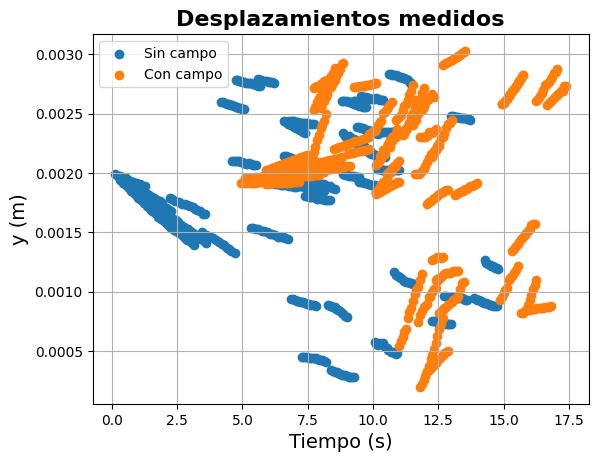

In [55]:
import itertools
flat_pos1 = list(itertools.chain.from_iterable(pos1))
flat_tiem1 = list(itertools.chain.from_iterable(tiem1))
flat_pos2 = list(itertools.chain.from_iterable(pos2))
flat_tiem2 = list(itertools.chain.from_iterable(tiem2))
plt.scatter( flat_tiem1,flat_pos1)
plt.scatter( flat_tiem2,flat_pos2)
plt.title("Desplazamientos medidos",fontsize=16,fontweight='bold')
plt.ylabel("y (m)", fontsize=14)
plt.xlabel("Tiempo (s)", fontsize=14)
plt.legend(['Sin campo','Con campo'])
plt.grid()
plt.show()

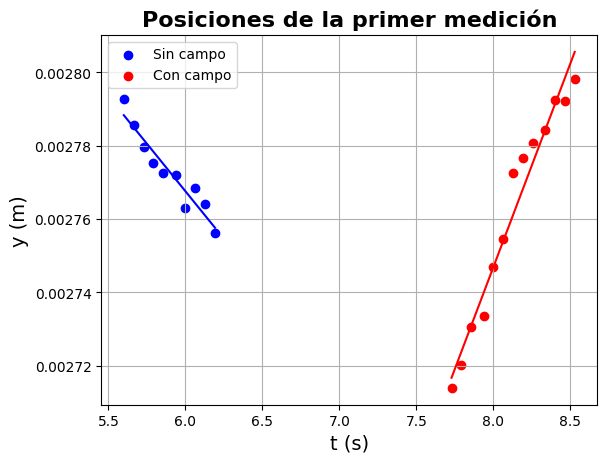

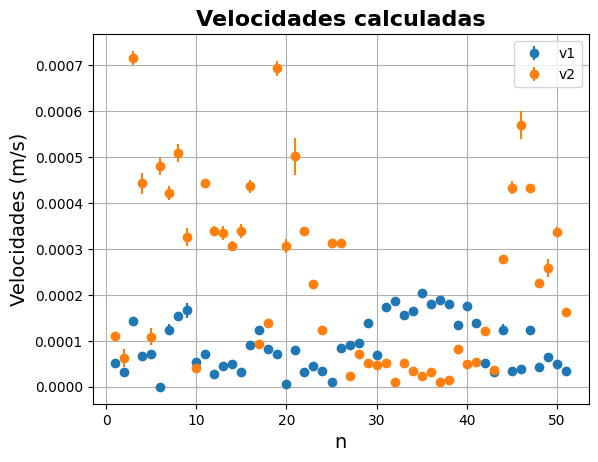

In [82]:
from scipy.stats import linregress
v1=[]
v2=[]
er1=[]
er2=[]
for i in range(0,51):
  x1=tiem1[i]
  y1=pos1[i]
  x2=tiem2[i]
  y2=pos2[i]
  resultado = linregress(x1, y1)
  v1.append(abs(resultado.slope))
  er1.append(resultado.stderr)
  resultado2 = linregress(x2, y2)
  v2.append(abs(resultado2.slope))
  er2.append(resultado2.stderr)
  if i==0:
    plt.scatter(x1,y1,color='blue')
    plt.scatter(x2,y2,color='red')
    plt.plot(x1,resultado.intercept + resultado.slope*np.array(x1),color='blue')
    plt.plot(x2,resultado2.intercept + resultado2.slope*np.array(x2),color='red')
    plt.title("Posiciones de la primer medición",fontsize=16,fontweight='bold')
    plt.ylabel("y (m)", fontsize=14)
    plt.xlabel("t (s)", fontsize=14)
    plt.legend(['Sin campo','Con campo'])
    plt.grid()
    plt.show()
v1=np.array(v1)
v2=np.array(v2)
er1=np.array(er1)
er2=np.array(er2)
plt.errorbar(list(range(1,52)),v1,yerr=er1,fmt='o')
plt.errorbar(list(range(1,52)),v2,yerr=er2,fmt='o')
plt.title("Velocidades calculadas",fontsize=16,fontweight='bold')
plt.ylabel("Velocidades (m/s)", fontsize=14)
plt.xlabel("n", fontsize=14)
plt.legend(['v1','v2'])
plt.grid()
plt.show()

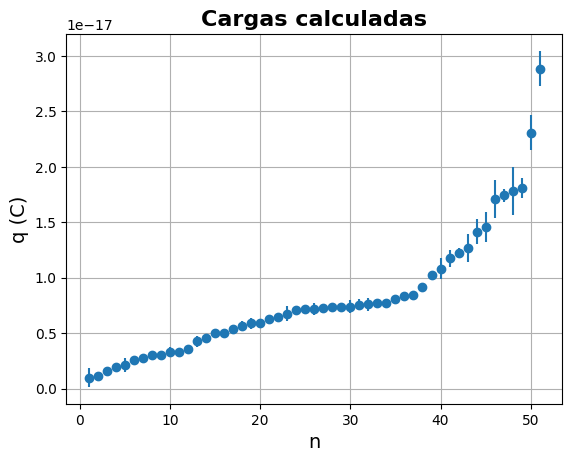

In [57]:
etha=1.825*10**(-5)
d=0.005
V=60
g=9.78
sig=870
rho=1.204
A=4/3 *ma.pi * ((9*etha)/2)**(3/2)*d/(V*ma.sqrt(g*(sig-rho)))
def q(v,w):
  a=A*(v+w)*np.sqrt(v)
  return a
def sigv1(v,w,dv):
  a=A*(3*v+w)/(2*np.sqrt(v))*dv
  return a
def sigv2(v,w,dw):
  a=A*np.sqrt(v)*dw
  return a
qn=q(v1,v2)
error=sigv1(v1,v2,er1)+sigv2(v1,v2,er2)
orden=sorted(zip(qn, error))
qnord, errorord = zip(*orden)
qnord=list(qnord)
errorord=list(errorord)
n=list(range(1,len(qnord)+1))
plt.errorbar(n,qnord,yerr=errorord,fmt='o')
plt.title("Cargas calculadas",fontsize=16,fontweight='bold')
plt.ylabel("q (C)", fontsize=14)
plt.xlabel("n", fontsize=14)
plt.grid()
plt.show()

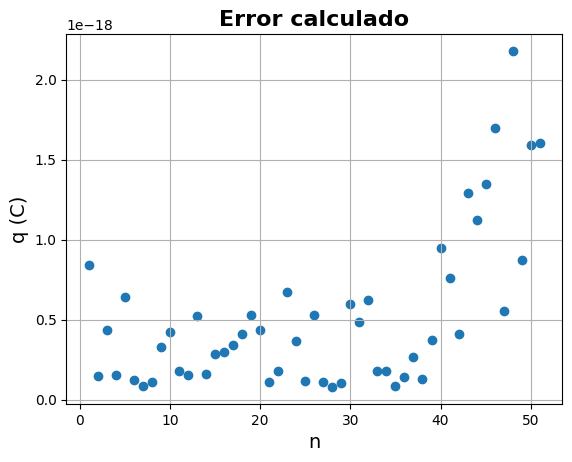

In [58]:
plt.scatter(n,errorord)
plt.title("Error calculado",fontsize=16,fontweight='bold')
plt.ylabel("q (C)", fontsize=14)
plt.xlabel("n", fontsize=14)
plt.grid()
plt.show()


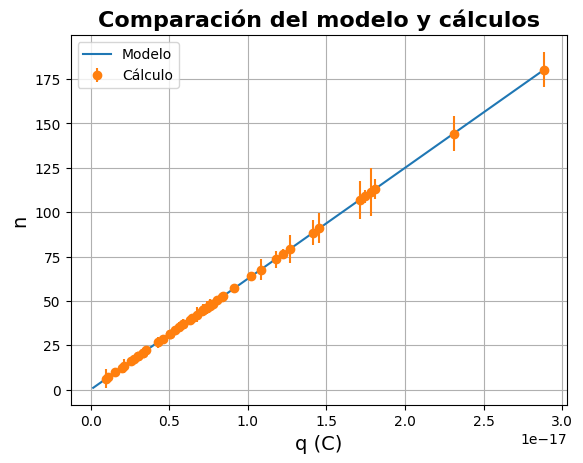

In [76]:
N=[k/(1.6*10**(-19)) for k in qnord]
Nerr=[k/(1.6*10**(-19)) for k in errorord]
Num=np.linspace(1,round(N[len(N)-1]))
plt.plot(1.6*10**(-19)*Num,Num)
plt.errorbar(qnord,N,yerr=Nerr,fmt='o')
plt.title("Comparación del modelo y cálculos",fontsize=16,fontweight='bold')
plt.ylabel("n", fontsize=14)
plt.xlabel("q (C)", fontsize=14)
plt.legend(['Modelo','Cálculo'])
plt.grid()
plt.show()

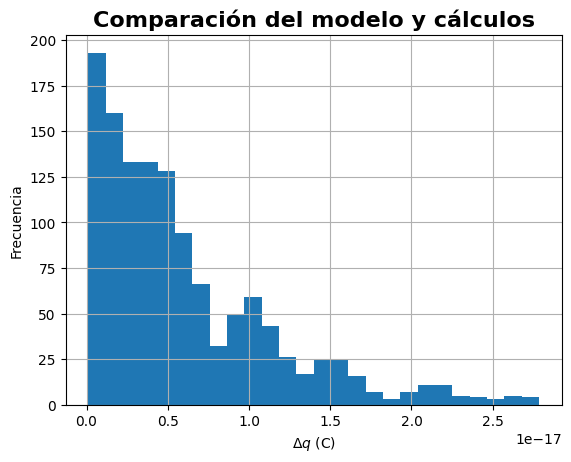

1.0078915717914663e-19


In [75]:
dq = []
for i in range(len(qnord)):
    for j in range(i+1, len(qnord)):
        dq.append(abs(qnord[j] - qnord[i]))
dq = [x for x in dq if x > 1e-19]
plt.hist(dq, bins=26)
plt.xlabel(r'$\Delta q$ (C)')
plt.ylabel('Frecuencia')
plt.title("Comparación del modelo y cálculos",fontsize=16,fontweight='bold')
plt.grid()
plt.show()
print(min(dq))

In [74]:
import numpy as np

e_candidatos = np.linspace(1e-20, 3e-19, 10000)

error = []

for e in e_candidatos:
    residuo = 0

    for qi in qnord:
        n = round(qi/e)
        residuo += (qi - n*e)**2

    error.append(residuo)

e_mejor = e_candidatos[np.argmin(error)]

print("e =", e_mejor)
e_ind = [qi/round(qi/e_mejor) for qi in qnord]
e_prom = np.mean(e_ind)
e_err = [dq/round(qi/e_mejor) for dq, qi in zip(errorord, qnord)]
e_err_prom = np.mean(e_err)
print("e_prom =", e_prom)
print("e_std =", e_err_prom)

e = 1.0667066706670667e-20
e_prom = 1.0666814680946024e-20
e_std = 8.926221586318068e-22
